# Balanced photo mosaic — walkthrough

A photomosaic rebuilds one picture out of many smaller ones. The usual way to do it
is to give every cell the tile that is closest in colour, which works until the
target has a large flat region — then the same tile wins thousands of times and the
result looks like wallpaper.

This walkthrough takes the two decisions apart:

1. Look at the target and the tiles.
2. **Which tile goes where** — nearest colour, or a shuffled sequence that uses
   every tile equally.
3. **What is done to it once it is there** — matching the tile's colour statistics
   to the patch it covers.
4. Why `meanstd` makes tiles disappear in flat regions and reappear on edges.
5. Build all three and compare.

Run `python fetch_example.py --target wave --tiles emoji` first, or let the first
cell do it. Needs `pillow`, `numpy` and `matplotlib`.

In [1]:
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from photomosaic import (  # noqa: E402
    build_mosaic_random, color_match_pixels, load_target, load_tiles,
    make_balanced_assignments, nearest_tile, tile_mean_colors, _to_np_rgb,
)

EXAMPLE = ROOT / "examples" / "wave-emoji"
if not (EXAMPLE / "target.jpg").exists():
    subprocess.run([sys.executable, "fetch_example.py", "--target", "wave",
                    "--tiles", "emoji"], cwd=ROOT, check=True)

TILE_SIZE, ENLARGEMENT, SEED = 32, 6, 12345
plt.rcParams.update({"figure.dpi": 90, "figure.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False})
print(EXAMPLE)

C:\Codes\balanced-photo-mosaic\examples\wave-emoji


## 1. The inputs

A target picture, and a folder of tiles. `load_target` enlarges the target and crops
it so its dimensions are exact multiples of the tile size; `load_tiles` centre-crops
each tile to a square.

The grid is what matters: enlarging by 6 and cutting into 32-pixel tiles gives about
twenty thousand cells, each of which needs a tile.

Reading tiles from C:\Codes\balanced-photo-mosaic\examples\wave-emoji\tiles ...


Loaded 1200 tiles total.
target (5760, 3840) -> grid 180 x 120 = 21,600 cells
1,200 tiles, so every tile is needed about 18 times


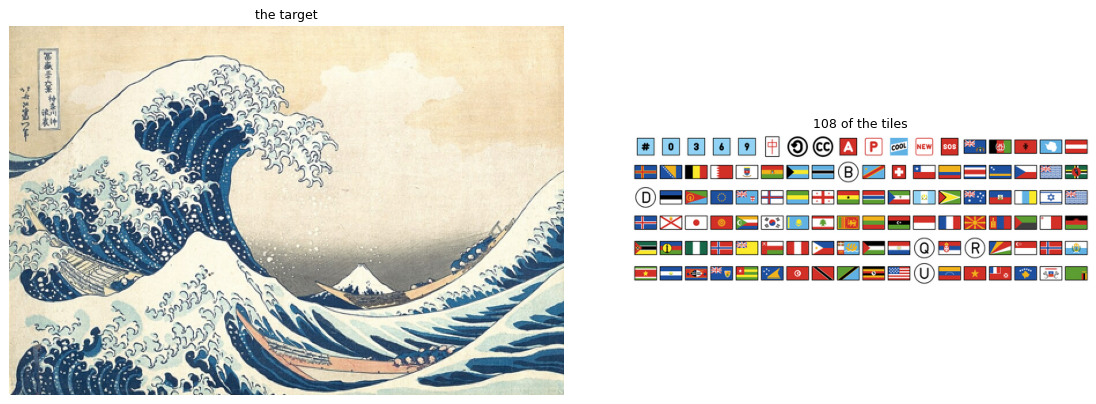

In [2]:
target = load_target(str(EXAMPLE / "target.jpg"), ENLARGEMENT, TILE_SIZE)
tiles = load_tiles(str(EXAMPLE / "tiles"), TILE_SIZE)

x_count, y_count = target.size[0] // TILE_SIZE, target.size[1] // TILE_SIZE
total_cells = x_count * y_count
print(f"target {target.size} -> grid {x_count} x {y_count} = {total_cells:,} cells")
print(f"{len(tiles):,} tiles, so every tile is needed about {total_cells/len(tiles):.0f} times")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [3, 2]})
axes[0].imshow(target.resize((target.width // 12, target.height // 12)))
axes[0].set_axis_off(); axes[0].set_title("the target", fontsize=10)
strip = np.vstack([np.hstack([np.asarray(t) for t in tiles[i*18:(i+1)*18]]) for i in range(6)])
axes[1].imshow(strip); axes[1].set_axis_off(); axes[1].set_title("108 of the tiles", fontsize=10)
fig.tight_layout()

## 2. Which tile goes where

The conventional choice is the nearest tile by average colour. Nothing stops it
answering the same way over and over, and in a picture that is one third sky, it
does.

Deciding this does not require rendering anything, so both strategies can be
compared on the grid alone.

In [3]:
tile_means = tile_mean_colors(tiles)
patch_means = np.zeros((total_cells, 3), dtype=np.float32)
patch_stds = np.zeros(total_cells, dtype=np.float32)
for index in range(total_cells):          # one pass; both statistics are wanted later
    xi, yi = index % x_count, index // x_count
    box = (xi*TILE_SIZE, yi*TILE_SIZE, (xi+1)*TILE_SIZE, (yi+1)*TILE_SIZE)
    patch = _to_np_rgb(list(target.crop(box).getdata()))
    patch_means[index] = patch.mean(axis=0)
    patch_stds[index] = patch.std(axis=0).mean()

# Nearest tile for every cell at once: |patch - tile|^2 over the whole grid.
gaps = ((patch_means[:, None, :] - tile_means[None, :, :]) ** 2).sum(axis=2)
nearest_choice = gaps.argmin(axis=1)
balanced_choice = np.array(make_balanced_assignments(len(tiles), total_cells,
                                                     __import__("random").Random(SEED)))

for name, choice in (("nearest", nearest_choice), ("balanced", balanced_choice)):
    counts = np.bincount(choice, minlength=len(tiles))
    print(f"{name:>9}: {int((counts > 0).sum()):>5} / {len(tiles)} tiles used, "
          f"most-used covers {counts.max() / total_cells:6.1%} of the mosaic")

  nearest:   436 / 1200 tiles used, most-used covers  22.5% of the mosaic
 balanced:  1200 / 1200 tiles used, most-used covers   0.1% of the mosaic


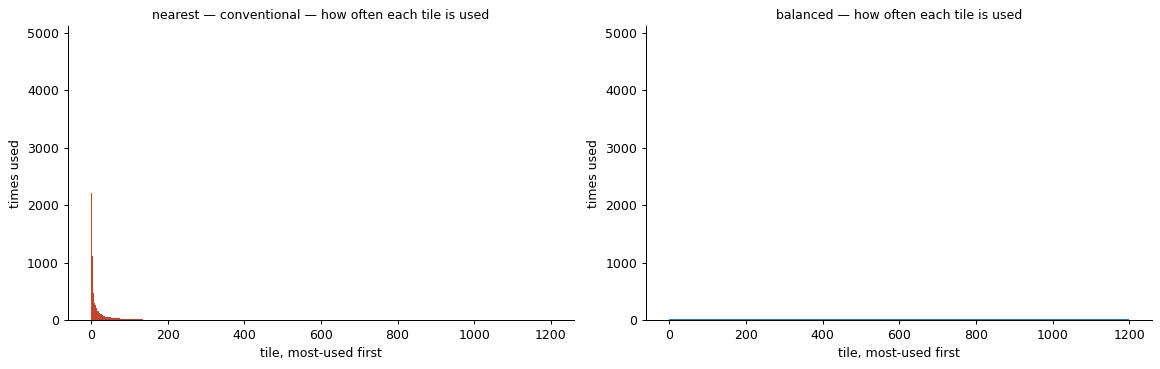

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, (name, choice, colour) in zip(axes, [
        ("nearest — conventional", nearest_choice, "#c2452f"),
        ("balanced", balanced_choice, "#2a7ac0")]):
    counts = np.bincount(choice, minlength=len(tiles))
    ax.bar(np.arange(len(tiles)), np.sort(counts)[::-1], width=1.0, color=colour, linewidth=0)
    ax.set_title(f"{name} — how often each tile is used", fontsize=10)
    ax.set_xlabel("tile, most-used first"); ax.set_ylabel("times used")
    ax.set_ylim(0, max(np.bincount(nearest_choice, minlength=len(tiles)).max(), 1) * 1.05)
fig.tight_layout()

The left plot is the whole argument. A handful of tiles take thousands of cells each
and most of the set is never used at all; the right-hand plot is flat by
construction.

Balance alone would give a random-looking image, though. What rescues the likeness
is the second step.

## 3. Recolouring a tile to fit its patch

Whatever tile arrives, its colours are shifted to match the patch it covers.

- `mean` moves the tile's average to the patch's average and changes nothing else.
- `meanstd` also rescales the spread: `(tile - mean_t) * (std_g/std_t) + mean_g`.
- `luma` does that to brightness alone, in YUV, leaving the hues alone.

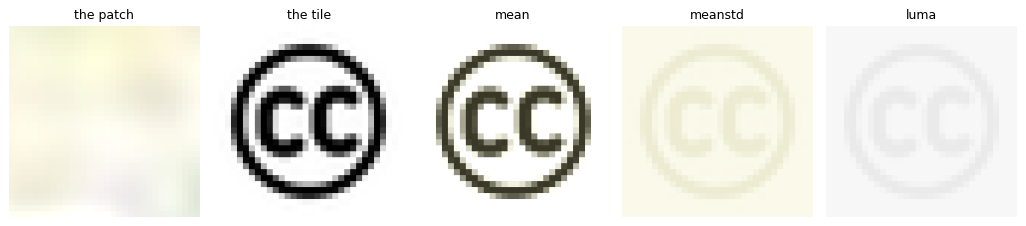

In [5]:
patch_index = total_cells // 2 + x_count // 4
xi, yi = patch_index % x_count, patch_index // x_count
box = (xi*TILE_SIZE, yi*TILE_SIZE, (xi+1)*TILE_SIZE, (yi+1)*TILE_SIZE)
patch_px = list(target.crop(box).getdata())
tile_px = list(tiles[7].getdata())


def as_image(pixels):
    art = Image.new("RGB", (TILE_SIZE, TILE_SIZE))
    art.putdata(pixels)
    return art.resize((TILE_SIZE*6, TILE_SIZE*6), Image.NEAREST)


panels = [("the patch", patch_px), ("the tile", tile_px)]
panels += [(mode, color_match_pixels(tile_px, patch_px, mode=mode))
           for mode in ("mean", "meanstd", "luma")]
fig, axes = plt.subplots(1, len(panels), figsize=(2.3*len(panels), 2.8))
for ax, (name, pixels) in zip(axes, panels):
    ax.imshow(as_image(pixels)); ax.set_axis_off(); ax.set_title(name, fontsize=10)
fig.tight_layout()

## 4. Why `meanstd` hides tiles in flat regions

The gain in `meanstd` is `std_patch / std_tile`. It has a consequence that is easy
to miss and turns out to be the nicest thing about this mode.

An emoji has strong internal contrast. A patch of open sky has almost none. The
ratio is therefore tiny, the tile's own contrast is crushed almost to nothing, and
what is left is a flat square of sky colour — the tile has disappeared. Along the
edge of the wave the patch's own contrast is high, the ratio approaches one, and the
tile survives intact.

So the tiles are visible exactly where the target has detail.

65% of cells keep under a quarter of their tile's contrast


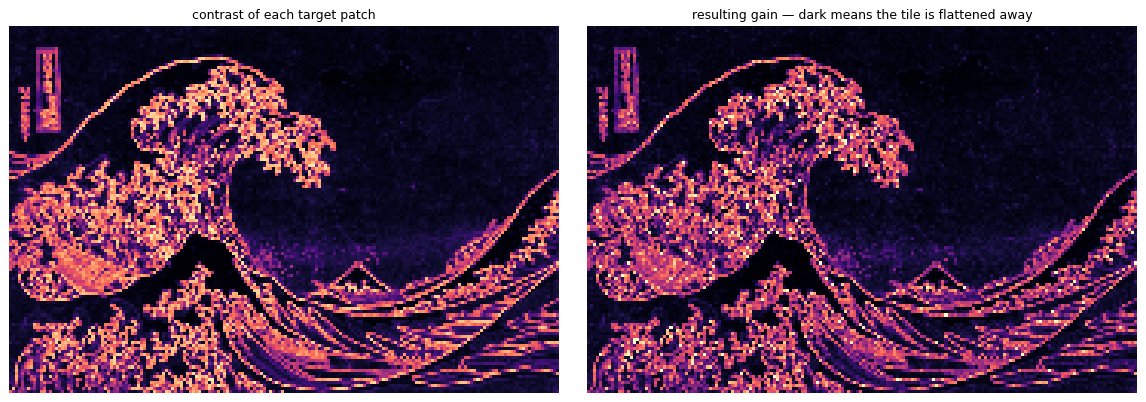

In [6]:
tile_stds = np.array([np.asarray(t, np.float32).reshape(-1, 3).std(axis=0).mean() for t in tiles])
gain = patch_stds / tile_stds[balanced_choice]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].imshow(patch_stds.reshape(y_count, x_count), cmap="magma")
axes[0].set_axis_off(); axes[0].set_title("contrast of each target patch", fontsize=10)
axes[1].imshow(np.clip(gain, 0, 1.5).reshape(y_count, x_count), cmap="magma")
axes[1].set_axis_off()
axes[1].set_title("resulting gain — dark means the tile is flattened away", fontsize=10)
fig.tight_layout()
print(f"{(gain < 0.25).mean():.0%} of cells keep under a quarter of their tile's contrast")

## 5. Build them

Same target, same tiles, three combinations. `build_mosaic_random` prints the tile
usage at the end of each run, which is the number worth watching.

In [7]:
runs = {
    "conventional": dict(select="nearest", recolor=False, mode="meanstd"),
    "balanced + mean": dict(select="balanced", recolor=True, mode="mean"),
    "balanced + meanstd": dict(select="balanced", recolor=True, mode="meanstd"),
}
made = {}
for name, options in runs.items():
    path = EXAMPLE / f"nb_{name.replace(' + ', '_').replace(' ', '_')}.jpg"
    print(f"--- {name}")
    build_mosaic_random(target_big=target, tiles=tiles, seed=SEED,
                        out_path=str(path), tile_size=TILE_SIZE, **options)
    made[name] = path

--- conventional
Grid: 180 x 120 = 21600 tiles (nearest selection, untouched)


Tile usage: 436/1200 tiles used, most-used appears 4,863 times (22.5% of the mosaic)
Finished. Wrote C:\Codes\balanced-photo-mosaic\examples\wave-emoji\nb_conventional.jpg
--- balanced + mean
Grid: 180 x 120 = 21600 tiles (balanced selection, recoloured)



Tile usage: 1200/1200 tiles used, most-used appears 18 times (0.1% of the mosaic)
Finished. Wrote C:\Codes\balanced-photo-mosaic\examples\wave-emoji\nb_balanced_mean.jpg
--- balanced + meanstd
Grid: 180 x 120 = 21600 tiles (balanced selection, recoloured)



Tile usage: 1200/1200 tiles used, most-used appears 18 times (0.1% of the mosaic)
Finished. Wrote C:\Codes\balanced-photo-mosaic\examples\wave-emoji\nb_balanced_meanstd.jpg


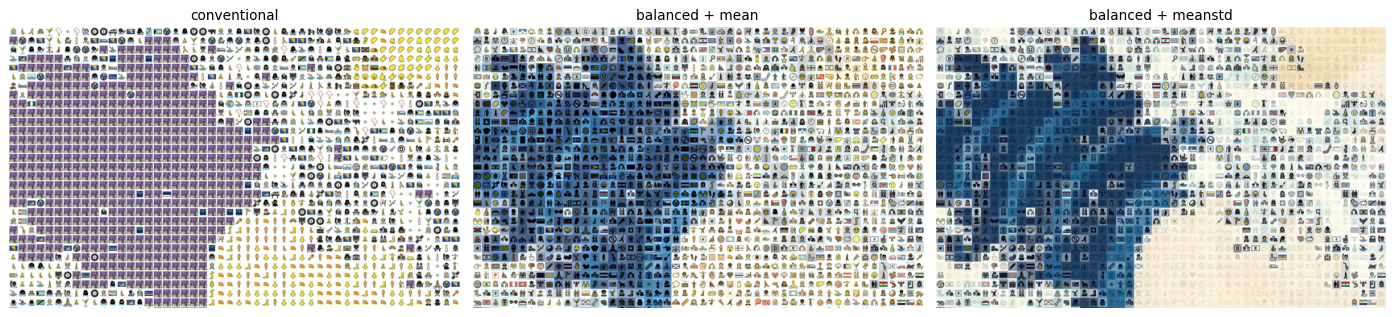

In [8]:
ZOOM = (1600, 700, 3200, 1700)
fig, axes = plt.subplots(1, len(made), figsize=(5.2*len(made), 3.6))
for ax, (name, path) in zip(axes, made.items()):
    ax.imshow(Image.open(path).crop(ZOOM).resize((560, 350), Image.LANCZOS))
    ax.set_axis_off(); ax.set_title(name, fontsize=11)
fig.tight_layout()

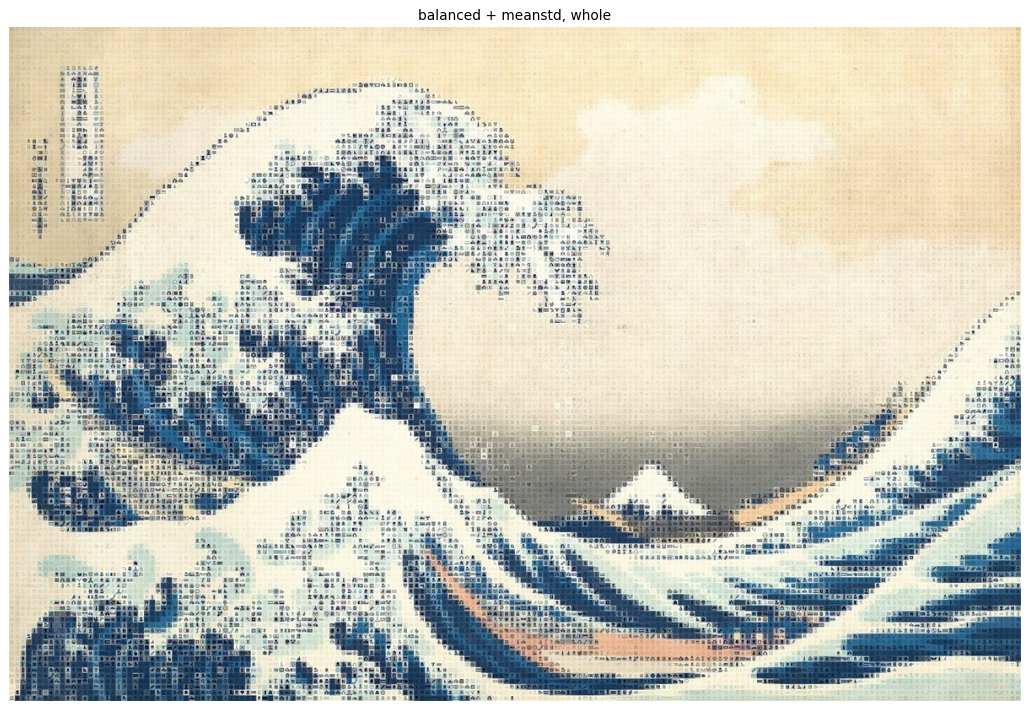

In [9]:
fig, ax = plt.subplots(figsize=(12, 8))
whole = Image.open(made["balanced + meanstd"])
ax.imshow(whole.resize((1200, int(1200 * whole.height / whole.width)), Image.LANCZOS))
ax.set_axis_off(); ax.set_title("balanced + meanstd, whole", fontsize=11)
fig.tight_layout()